In [1]:
import Pkg; Pkg.activate("/home/henkes/.julia/environments/l200-dev")

  Activating project at `~/.julia/environments/l200-dev`


In [2]:
include("/nfs/scratch/henkes/l200/legend-julia-dataflow/src/startup.jl")

┌ Warning: No debug flag set
└ @ Main /nfs/scratch/henkes/l200/legend-julia-dataflow/src/startup.jl:7


Task (done) @0x00007fb639723850

In [3]:
period = DataPeriod(3)
run = DataRun(0)
l200 = LegendData(:l200)
reprocess=true
timeout=3600
max_wvfs=15000
ENV["JULIA_DEBUG"] = Main

Main

In [4]:
l200.tier[:raw, :cal, :p03, :r000]

"/lfs/l1/legend/data/public/prodenv/prod-blind/ref-raw/generated/tier/raw/cal/p03/r000"

In [5]:
@info "Process DSP for period $period and run $run"

filekeys = search_disk(FileKey, l200.tier[:raw, :cal, period, run])

filekey = start_filekey(l200, (period, run, :cal))
@info "Found start filekey $filekey"

chinfo = Table(channelinfo(l200, filekey; system=:geds, only_processable=true))
@info "Loaded channel info with $(length(chinfo)) channels"

dsp_config = DSPConfig(dataprod_config(l200).dsp(filekey).default)
@debug "Loaded DSP config: $(dsp_config)"

train_data = h5open(get_mltrainfilename(l200, filekey))
f_evaluate_qc = get_qc_ml_func(Array(train_data["ml_train/dsp/dwt_norm"]), Array(train_data["ml_train/dsp/dc_label"]), l200.par.rpars.ml(filekey))
close(train_data)

@info "Loaded trained SVM model"
pars_tau = get_values(l200.par.rpars.pz[period, run])
@debug "Loaded decay times"

pars_fltoptimization = get_values(merge(l200.par.rpars.fltopt[period, run], l200.par.rpars.aoeopt[period, run]))
@debug "Loaded optimization parameters"

@debug "Create DSP folder: $(mkpath(l200.tier[:jldsp, :cal, period, run]))"

if reprocess 
    @info "Reprocess all filekeys and channels"
else
    @info "Only reprocess filekeys and channels that are not processed yet"
end

# create log line Tuple
log_nt = NamedTuple{(:Filekey, :Status, Symbol("Number of Processed Detectors"), Symbol("Failed Detectors"), Symbol("Total Time"), Symbol("Total Allocated"), :Error)}

# get worker pool
wpool = default_worker_pool()

[ Info: Process DSP for period p03 and run r000
[ Info: Found start filekey l200-p03-r000-cal-20230311T235840Z
[ Info: Loaded channel info with 89 channels
┌ Debug: Loaded DSP config: DSPConfig{Float64}(40.0 μs, 41.0 μs, 41.0 μs,
│ 38.0 μs, 38.0 μs, 4.0, 5.0, 3, 0.0 μs .. 39.0 μs, 70.0 μs .. 110.0 μs,
│ 20.0 μs .. 100.0 μs, (2.5:0.1:5.0) μs, (2.5:0.1:5.0) μs, (2.0:0.5:16.0)
│ μs, (1.0:0.2:4.0) μs, (1.5:0.5:16.0) μs, (1.0:0.2:4.0) μs, (1.5:0.5:16.0)
│ μs, (1.0:0.2:4.0) μs, (30.0:32.0:350.0) ns, PropDict(:zac => PropDict(:ft
│ => 100.0 μs, :rt => 100.0 μs), :cusp => PropDict(:ft => 100.0 μs, :rt =>
│ 100.0 μs), :trap => PropDict(:ft => 100.0 μs, :rt => 100.0 μs), :sg =>
│ 100.0 ns), PropDict(:intracemintot => 100.0 ns, :t0fltpars =>
│ Quantity{Float64, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}[40.0 ns, 100.0
│ ns, 2000.0 ns], :txmintot => 1000.0 ns, :siginterpolationlength => 100 ns,
│ :t0mintot => 1500.0 ns, :fcbitdepth => 16, :siginterpolation_order => 3))
└ @ Main /nfs/scratch/henkes/l

WorkerPool(Channel{Int64}(9223372036854775807), Set{Int64}(), RemoteChannel{Channel{Any}}(1, 1, 1))

In [6]:
fk = filekeys[1]

FileKey("l200-p03-r000-cal-20230311T235840Z")

In [7]:
# dsp_timer = TimerOutput()
# # raw and dsp filename
# rawfilename    = l200.tier[:raw, fk]
# @info "Processing file: $(basename(rawfilename))"
# dspfilename = l200.tier[:jldsp, fk]
# @info "Using output file: $(basename(dspfilename))"
# # number of processed detectors
# n_detectors = 0
# # channel ids of failed detectors
# failed_detectors = DetectorId[]
# # start processing
# read_files(rawfilename, use_cache = false) do filename
#     modify_files(dspfilename, use_cache = true) do outfilename
#         @timeit dsp_timer "Startup" begin
#             raw_data = lh5open(filename, "r")
#             if reprocess && isfile(dspfilename)
#                 @info "Reprocess $(basename(dspfilename)), remove old DSP."
#                 rm(outfilename, force=true)
#             else
#                 try
#                     close(lh5open(outfilename, "r"))
#                 catch e
#                     @warn "LoadError: $e"
#                     @warn "Filename $(basename(dspfilename)) seems broken, remove old DSP."
#                     rm(outfilename, force=true)
#                 end
#             end
#         end

#         processed_channels = keys(lh5open(outfilename, "cw"))

#         @info "Start DSP"
#         @timeit dsp_timer "DSP" begin
#             # loop over channels
#             @showprogress desc="Filekey: $fk" for (ch, det) in zip(chinfo.channel, chinfo.detector)

#                 # check if channel can be processed
#                 if "$ch" in processed_channels && !reprocess
#                     @info "Detector $det ($ch) already processed, skip"
#                     n_detectors += 1
#                     continue
#                 end
#                 # check for decay time
#                 if !haskey(pars_tau, det)
#                     @warn "No decay time for detector $det, skip channel $ch"
#                     push!(failed_detectors, det)
#                     continue
#                 end
#                 # check if channel has values for RT and FT for different filters
#                 if !haskey(pars_fltoptimization, det)
#                     @warn "No optimization parameters for detector $det, skip channel $ch"
#                     push!(failed_detectors, det)
#                     continue
#                 end

#                 @debug "Processing channel $ch ($det)"
#                 error_dets = ""
#                 @timeit dsp_timer "DSP $det" begin
#                     # process data
#                     outdata_ch = nothing
#                     try
#                         raw_data_ch = raw_data[ch].raw[:]
#                         outdata_ch = fast_flatten([dsp_icpc(data_part, dsp_config, pars_tau[det].tau, pars_fltoptimization[det]; f_evaluate_qc=f_evaluate_qc)
#                                 for data_part in Iterators.partition(raw_data_ch, max_wvfs)])
#                     catch e
#                         if e isa TaskFailedException
#                             e = e.task.exception
#                         end
#                         @error "Error processing channel $ch ($det) in $(fk): $e"
#                         push!(failed_detectors, det)
#                         continue
#                     end
#                     # save data to hdf5
#                     lh5open(outfilename, "cw") do outdata
#                         outdata[ch, :jldsp] = outdata_ch
#                     end
#                     # free memory
#                     GC.gc()
#                     # count number of detectors processed and Successful
#                     n_detectors += 1
#                 end
#             end
#         end

#         @info "Finished processing file: $(basename(filename))"
#         close(raw_data)
#     end
# end
# if n_detectors == 0
#     @warn "No detectors processed in $(basename(filename))"
# end

# # create total timer by summing over memory usage and time
# total_time      = canonicalize(Dates.Nanosecond(TimerOutputs.tottime(dsp_timer)))
# total_allocated = Base.format_bytes(TimerOutputs.totallocated(dsp_timer))

# # create log
# log_fk = log_nt((fk, ProcessStatus(1), "$(n_detectors)/$(length(chinfo))", string.(failed_detectors), total_time, total_allocated, ""))

In [8]:
raw_data = lh5open(l200.tier[:raw, fk], "r")
ch, det = chinfo.channel[1], chinfo.detector[1]
raw_data_ch = raw_data[ch].raw[:]

Table with 36 columns and 3909 rows:
      packet_id  eventnumber  timestamp    runtime     numtraces  ⋯
    ┌──────────────────────────────────────────────────────────────
 1  │ 297        6            1.67858e9 s  0.855686 s  1          ⋯
 2  │ 370        8            1.67858e9 s  0.872903 s  1          ⋯
 3  │ 690        17           1.67858e9 s  0.950611 s  1          ⋯
 4  │ 764        21           1.67858e9 s  0.970691 s  1          ⋯
 5  │ 1098       29           1.67858e9 s  1.05676 s   1          ⋯
 6  │ 1124       30           1.67858e9 s  1.06221 s   1          ⋯
 7  │ 1406       37           1.67858e9 s  1.13257 s   1          ⋯
 8  │ 1480       38           1.67858e9 s  1.15192 s   1          ⋯
 9  │ 1711       43           1.67858e9 s  1.20664 s   1          ⋯
 10 │ 2085       47           1.67858e9 s  1.30175 s   1          ⋯
 11 │ 2152       51           1.67858e9 s  1.31667 s   1          ⋯
 12 │ 2333       56           1.67858e9 s  1.35559 s   1          ⋯
 13 │ 2629 

In [9]:
using RadiationDetectorDSP, ArraysOfArrays, IntervalSets
plotlyjs()
data, config, τ, pars_filter = raw_data_ch, dsp_config, pars_tau[det].tau, pars_fltoptimization[det]

(@NamedTuple{packet_id::UInt32, eventnumber::Int32, timestamp::Quantity{Float64, 𝐓, Unitful.FreeUnits{(s,), 𝐓, nothing}}, runtime::Quantity{Float64, 𝐓, Unitful.FreeUnits{(s,), 𝐓, nothing}}, numtraces::Int32, tracelist::Vector{Int16}, baseline::UInt16, daqenergy::UInt16, channel::UInt32, ts_pps::Int32, ts_ticks::Int32, ts_maxticks::Int32, mu_offset_sec::Int32, mu_offset_usec::Int32, to_master_sec::Int32, delta_mu_usec::Int32, abs_delta_mu_usec::Int32, to_start_sec::Int32, to_start_usec::Int32, dr_start_pps::Int32, dr_start_ticks::Int32, dr_stop_pps::Int32, dr_stop_ticks::Int32, dr_maxticks::Int32, deadtime::Float64, event_type::UInt8, fcid::UInt8, crate::UInt8, slot::UInt8, board_id::UInt16, fc_input::UInt8, waveform_windowed::RadiationDetectorSignals.RDWaveform{Quantity{Float32, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Int32, StepRangeLen{Quantity{Float32, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Quantity{Float64, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Quantity{Float64, 𝐓, Unitful

In [10]:
columnnames(data)

(:packet_id, :eventnumber, :timestamp, :runtime, :numtraces, :tracelist, :baseline, :daqenergy, :channel, :ts_pps, :ts_ticks, :ts_maxticks, :mu_offset_sec, :mu_offset_usec, :to_master_sec, :delta_mu_usec, :abs_delta_mu_usec, :to_start_sec, :to_start_usec, :dr_start_pps, :dr_start_ticks, :dr_stop_pps, :dr_stop_ticks, :dr_maxticks, :deadtime, :event_type, :fcid, :crate, :slot, :board_id, :fc_input, :waveform_windowed, :presum_rate, :waveform_presummed, :t_sat_lo, :t_sat_hi)

In [11]:
 # get config parameters
 bl_window                = config.bl_window
 t0_threshold             = config.t0_threshold
 tail_window              = config.tail_window
 inTraceCut_std_threshold = config.inTraceCut_std_threshold
 sg_flt_degree            = config.sg_flt_degree
 current_window           = config.current_window
 qdrift_int_length        = config.qdrift_int_length
 lq_int_length            = config.lq_int_length
 
 # get optimal filter parameters
 trap_rt, trap_ft = LegendDSP.get_fltpars(pars_filter, :trap, config)
 cusp_rt, cusp_ft = LegendDSP.get_fltpars(pars_filter, :cusp, config)
 zac_rt, zac_ft = LegendDSP.get_fltpars(pars_filter, :zac, config)
 sg_wl   = LegendDSP.get_fltpars(pars_filter, :sg, config)

 # get waveform data 
 wvfs_pre = decode_data(data.waveform_presummed)
 wvfs_wdw = decode_data(data.waveform_windowed)
 presum_rate = data.presum_rate
 blfc = data.baseline
 ts   = data.timestamp
 evID = data.eventnumber
 efc  = data.daqenergy

 # get CUSP and ZAC filter length and flt scale
 flt_length_zac              = config.flt_length_zac
 zac_scale                   = ustrip(NoUnits, flt_length_zac/step(wvfs_pre[1].time))
 flt_length_cusp             = config.flt_length_cusp
 cusp_scale                  = ustrip(NoUnits, flt_length_cusp/step(wvfs_pre[1].time))

 # get number of samples the waveform is saturated at low and high of FADC range
 bit_depth = config.kwargs_pars.fc_bit_depth # of FlashCam FADC
 sat_low, sat_high = 0, 2^bit_depth - bit_depth
 sat_stats = saturation.(wvfs_pre, sat_low, sat_high)

  # set tau for CUSP filter to very high number to switch of CR filter
  τ_cusp = 10000000.0u"µs"
  τ_zac = 10000000.0u"µs"

1.0e7 μs

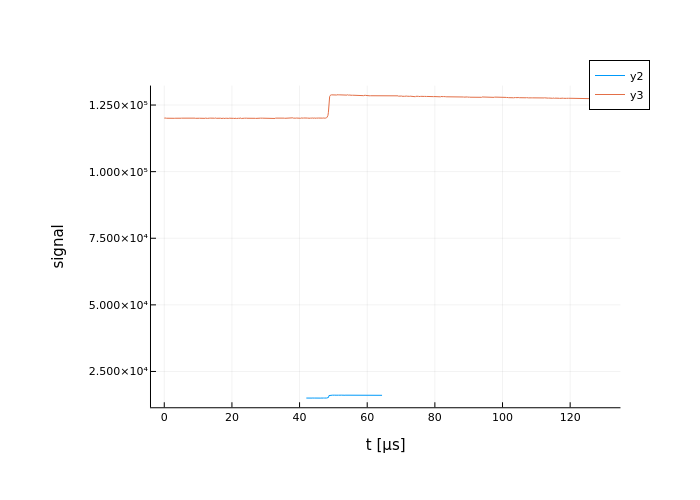

In [12]:
plot(u"µs", NoUnits, size=(800, 600))
plot!(wvfs_wdw[1])
plot!(wvfs_pre[1])

In [13]:
# get baseline mean, std and slope
 bl_stats = signalstats.(wvfs_pre, leftendpoint(bl_window), rightendpoint(bl_window))

 # pretrace difference 
 pretrace_diff = flatview(wvfs_wdw.signal)[1, :] - bl_stats.mean ./ presum_rate

 # substract baseline from waveforms
 wvfs_pre = shift_waveform.(wvfs_pre, -bl_stats.mean)
 wvfs_wdw = shift_waveform.(wvfs_wdw, -bl_stats.mean ./ presum_rate)

3909-element StructArray(::Vector{StepRangeLen{Quantity{Float32, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Quantity{Float64, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Quantity{Float64, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Int64}}, ::ArrayOfSimilarArrays{Float64, 1, 1, 2, Matrix{Float64}}) with eltype RadiationDetectorSignals.RDWaveform{Quantity{Float32, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Float64, StepRangeLen{Quantity{Float32, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Quantity{Float64, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Quantity{Float64, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Int64}, Vector{Float64}}:
 RadiationDetectorSignals.RDWaveform{Quantity{Float32, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Float64, StepRangeLen{Quantity{Float32, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Quantity{Float64, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Quantity{Float64, 𝐓, Unitful.FreeUnits{(ns,), 𝐓, nothing}}, Int64}, SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.On

In [ ]:
plot(u"µs", NoUnits, size=(800, 600))
plot!(wvfs_wdw[1])
plot!(wvfs_pre[1])

In [ ]:
# get QC classifier labels
qc_labels = zeros(length(wvfs_pre))
# if !ismissing(f_evaluate_qc)
#     qc_labels = get_qc_classifier(wvfs, f_evaluate_qc)
# end

# get wvf maximum
wvf_max_pre = maximum.(wvfs_pre.signal)
wvf_min_pre = minimum.(wvfs_pre.signal)

wvf_max_wdw = maximum.(wvfs_wdw.signal)
wvf_min_wdw = minimum.(wvfs_wdw.signal)


# extract decay times
tail_stats = tailstats.(wvfs_pre, leftendpoint(tail_window), rightendpoint(tail_window))

# deconvolute waveform 
# --> wvfs = wvfs_pz
deconv_flt = InvCRFilter(τ)
wvfs_pre = deconv_flt.(wvfs_pre)
wvfs_wdw = deconv_flt.(wvfs_wdw)

# get tail mean, std and slope
pz_stats = signalstats.(wvfs_pre, leftendpoint(tail_window), rightendpoint(tail_window))

In [ ]:
# t0 determination
t0 = get_t0(wvfs_wdw, t0_threshold; flt_pars=config.kwargs_pars.t0_flt_pars, mintot=config.kwargs_pars.t0_mintot)

# get threshold points in rise
t10 = get_threshold(wvfs_wdw, wvf_max_wdw .* 0.1; mintot=config.kwargs_pars.tx_mintot)
t50 = get_threshold(wvfs_wdw, wvf_max_wdw .* 0.5; mintot=config.kwargs_pars.tx_mintot)
t80 = get_threshold(wvfs_wdw, wvf_max_wdw .* 0.8; mintot=config.kwargs_pars.tx_mintot)
t90 = get_threshold(wvfs_wdw, wvf_max_wdw .* 0.9; mintot=config.kwargs_pars.tx_mintot)
t99 = get_threshold(wvfs_wdw, wvf_max_wdw .* 0.99; mintot=32u"ns")

drift_time = uconvert.(u"ns", t90 - t0)

In [ ]:
plot(u"µs", NoUnits, size=(800, 600))
plot!(wvfs_wdw[1])
plot!(wvfs_pre[1])
# vline!(first.([t0, t10, t50, t80, t90, t99]))
vline!(first.([t50]))

In [ ]:
# get Q-drift parameter
qdrift = get_qdrift(wvfs_wdw, t0, qdrift_int_length; pol_power=config.kwargs_pars.sig_interpolation_order, sign_est_length=config.kwargs_pars.sig_interpolation_length)

# get LQ parameter
lq  = get_qdrift(wvfs_wdw, t80, lq_int_length; pol_power=config.kwargs_pars.sig_interpolation_order, sign_est_length=config.kwargs_pars.sig_interpolation_length)

In [ ]:
# robust energy reconstruction with long, middle and short rise and flat-top times
uflt_10410 = TrapezoidalChargeFilter(10u"µs", 4u"µs")
e_10410  = maximum.((uflt_10410.(wvfs_pre)).signal)

uflt_535 = TrapezoidalChargeFilter(5u"µs", 3u"µs")
e_535  = maximum.((uflt_535.(wvfs_pre)).signal)

uflt_313 = TrapezoidalChargeFilter(3u"µs", 1u"µs")
e_313  = maximum.((uflt_313.(wvfs_pre)).signal)

# signal estimator for precise energy reconstruction
signal_estimator = SignalEstimator(PolynomialDNI(2, 50u"ns"))

# get trap energy of optimized rise and flat-top time
uflt_trap_rtft = TrapezoidalChargeFilter(trap_rt, trap_ft)

e_trap = signal_estimator.(uflt_trap_rtft.(wvfs_pre), t50 .+ (trap_rt + trap_ft/2))

# get cusp energy of optimized rise and flat-top time
uflt_cusp_rtft = CUSPChargeFilter(cusp_rt, cusp_ft, τ_cusp, flt_length_cusp, cusp_scale)

e_cusp = signal_estimator.(uflt_cusp_rtft.(wvfs_pre), t50 .+ (flt_length_cusp /2))

# get zac energy of optimized rise and flat-top time
uflt_zac_rtft = ZACChargeFilter(zac_rt, zac_ft, τ_zac, flt_length_zac, zac_scale)

e_zac = signal_estimator.(uflt_zac_rtft.(wvfs_pre), t50 .+ (flt_length_zac /2))

# extract current with optimal SG filter length with second order polynominal and first derivative
wvfs_sgflt_deriv = SavitzkyGolayFilter(sg_wl, sg_flt_degree, 1).(wvfs_wdw)
a_sg = get_wvf_maximum.(wvfs_sgflt_deriv, first(wvfs_wdw.time[1]), last(wvfs_wdw.time[1]))

a_60 = get_wvf_maximum.(SavitzkyGolayFilter(60u"ns", sg_flt_degree, 1).(wvfs_wdw), leftendpoint(current_window), rightendpoint(current_window))
a_100 = get_wvf_maximum.(SavitzkyGolayFilter(100u"ns", sg_flt_degree, 1).(wvfs_wdw), leftendpoint(current_window), rightendpoint(current_window))
a_raw = get_wvf_maximum.(DifferentiatorFilter(1).(wvfs_wdw), leftendpoint(current_window), rightendpoint(current_window))

# get in-trace pile-up
inTrace_pileUp = get_intracePileUp(wvfs_sgflt_deriv, inTraceCut_std_threshold, bl_window; mintot=config.kwargs_pars.intrace_mintot)

# get position of current rise
thres = maximum.(wvfs_sgflt_deriv.signal) .* 0.5
# replace!(thres, zero(thres[1]) => one(thres[1]))

t50_current = get_threshold(wvfs_sgflt_deriv, thres; mintot=config.kwargs_pars.tx_mintot)

# invert waveform for DC tagging
# wvfs --> wvfs_pz_inv
wvfs = multiply_waveform.(wvfs_pre, -1.0)

# get inverted waveform maximum for long and short filter
e_10410_max_inv  = maximum.(uflt_10410.(wvfs_pre).signal)

e_313_max_inv  = maximum.(uflt_313.(wvfs_pre).signal)

# t0 determination
t0_inv = get_t0(wvfs_pre, t0_threshold; mintot=config.kwargs_pars.t0_mintot)

In [ ]:
# output Table 
ret = TypedTables.Table(blmean = bl_stats.mean, blsigma = bl_stats.sigma, blslope = bl_stats.slope, bloffset = bl_stats.offset, 
tailmean = pz_stats.mean, tailsigma = pz_stats.sigma, tailslope = pz_stats.slope, tailoffset = pz_stats.offset,
qc_label = qc_labels,
t0 = t0, t10 = t10, t50 = t50, t80 = t80, t90 = t90, t99 = t99,
t50_current = t50_current, 
drift_time = drift_time,
tail_τ = tail_stats.τ, tail_mean = tail_stats.mean, tail_sigma = tail_stats.sigma,
e_max = wvf_max, e_min = wvf_min,
e_10410 = e_10410, e_535 = e_535, e_313 = e_313,
e_10410_inv = e_10410_max_inv, e_313_inv = e_313_max_inv,
t0_inv = t0_inv,
e_trap = e_trap, e_cusp = e_cusp, e_zac = e_zac, 
qdrift = qdrift, lq = lq,
a_sg = a_sg, a_60 = a_60, a_100 = a_100, a_raw = a_raw,
blfc = blfc, timestamp = ts, eventID_fadc = evID, e_fc = efc,
pretrace_diff = pretrace_diff, 
inTrace_intersect = inTrace_pileUp.intersect, inTrace_n = inTrace_pileUp.n,
n_sat_low = sat_stats.low, n_sat_high = sat_stats.high, n_sat_low_cons = sat_stats.max_cons_low, n_sat_high_cons = sat_stats.max_cons_high
)